# NSES discovery

Parse the `NSES` column correctly (fixes a thousands-separator artifact in the raw CSV), impute missing values, and visualize the result.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/boris_buddy_synth_dataset.csv", sep=";")
df["NSES"].describe()

count           16191
unique            888
top       0.680317744
freq              295
Name: NSES, dtype: object

## Parsing bug

`NSES` is read as text. ~39% of the non-null values have extra dots inserted as thousands separators, e.g. `-1.957.918.992` should be `-1.957918992`. Every cleanly-formatted value has exactly one digit before the decimal point, so the fix is: strip all dots, keep the sign, and re-insert the decimal point after the first digit.

In [2]:
def fix_nses(value):
    """Repair stray thousands-separator dots, e.g. '-1.957.918.992' -> -1.957918992."""
    if pd.isna(value):
        return None
    value = str(value)
    sign = ""
    if value.startswith("-"):
        sign, value = "-", value[1:]
    digits = value.replace(".", "")
    return float(sign + digits[0] + "." + digits[1:])


df["NSES"] = df["NSES"].apply(fix_nses)
df["NSES"].describe()

count    16191.000000
mean        -0.537768
std          1.087811
min         -7.121883
25%         -1.184359
50%         -0.565893
75%          0.211672
max          2.933054
Name: NSES, dtype: float64

## Impute missing values

9.85% of rows have no `NSES` value. The distribution has a heavy left tail (min ≈ -7 vs. max ≈ 3), so the median is a more robust fill value than the mean.

In [3]:
def impute_median(series):
    """Fill missing values with the column median. Returns (filled_series, missing_mask, fill_value)."""
    missing_mask = series.isna()
    fill_value = series.median()
    filled = series.fillna(fill_value)
    return filled, missing_mask, fill_value


df["NSES"], was_missing, nses_median = impute_median(df["NSES"])

print(f"missing before impute: {was_missing.sum()} ({was_missing.mean():.2%})")
print(f"imputed with median: {nses_median:.4f}")
print(f"missing after impute: {df['NSES'].isna().sum()}")

missing before impute: 1769 (9.85%)
imputed with median: -0.5659
missing after impute: 0


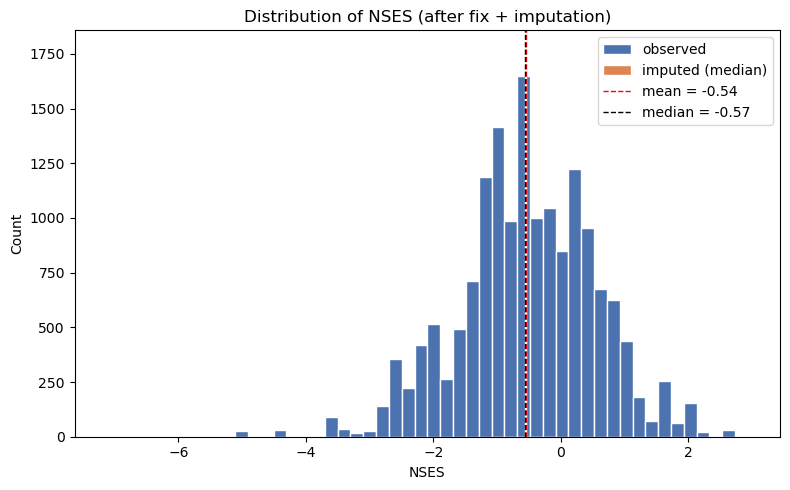

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(df.loc[~was_missing, "NSES"], bins=50, color="#4C72B0", edgecolor="white", label="observed")
ax.hist(df.loc[was_missing, "NSES"], bins=50, color="#DD8452", edgecolor="white", label="imputed (median)")

ax.axvline(df["NSES"].mean(), color="red", linestyle="--", linewidth=1, label=f"mean = {df['NSES'].mean():.2f}")
ax.axvline(nses_median, color="black", linestyle="--", linewidth=1, label=f"median = {nses_median:.2f}")

ax.set_title("Distribution of NSES (after fix + imputation)")
ax.set_xlabel("NSES")
ax.set_ylabel("Count")
ax.legend()
fig.tight_layout()
plt.show()